In [80]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

student-mav.csv gets loaded. Since it is stored with semicolons to separate features, we have to separte by that character.

In [81]:
try:
    dataFile = pd.read_csv('student-mat.csv', sep=';')
    print("-------------------------------------")
    print("Data successfully loaded")
    print(f"Object Count: {dataFile.shape[0]}") #Total number of students (rows)
    print(f"Attribute Count: {dataFile.shape[1]}") #Total number of features (columns)
    #print(f"Features: {list(dataFile.columns)}") 
except:
    print("student-mat.csv not found! Please make sure it is in the same directory as project.py!")
    sys.exit(0)


-------------------------------------
Data successfully loaded
Object Count: 395
Attribute Count: 33


G3 (The final grade of the student) is our target variable.

Columns are then split between three types: Binary, Nominal, and Numeric

Binary Columns: Columns with only two possible non-numeric values
Nominal Columns: Columns with more than two non-numeric values
Numeric Columns: Columns that are already numeric and can skip the encoding phase

In [82]:

ogAttributeCount = dataFile.shape[1]
#G3 is the final grade, which is what we are trying to predict. So X will contain everything but that for training
X = dataFile.drop('G3', axis=1)
y = dataFile['G3']
#Non-Numeric Features with only two possible values (M/F), (U/R), (GT3/LE3), (A/T) etc)
binaryColumns = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
#Non-numeric Features who's order does not matter, but can have more than two values (Health/Other/Teacher/Services), (Home/Other/Reputation), etc
nominalColumns = ['Mjob', 'Fjob', 'reason', 'guardian']
#Columns that are alraedy numeric and can skip the encoding phase
numericColumns = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


# Encoding 

For nominal columns, it is easiest to use One Hot Encoding. This will split the columns into however many binary columns we need. For example, Mjob will be split into Mjob_health, Mjob_other, Mjob_services, and Mjob_teacher. drop_first lets us remove one of the categories to avoid redundancy.

For binary columns, we don't need to use One Hot Encoding as simply transforming it into a 0 or 1 will be satisfactory enough without having to create new attributes

In [83]:
#X takes these attributes and performs One Hot Encoding (OHE)
#OHE splits the attribute into however many new attributes we need for our nominal columns
#We need to add drop_first=True So that our original column is gone and we don't have duplicate data. One will act as the reference point
#Not having drop_First=True will result in 4 redundant columns
X = pd.get_dummies(X, columns=nominalColumns, drop_first=True)
le = LabelEncoder()
for col in binaryColumns:
    #Converts our binary columns into 0's and 1's
    #We can use this instead of One Hot Encoding so that we dont have as many unnecessary attributes
    X[col] = le.fit_transform(X[col])
print("-------------------------------------")
print("Finished encoding.")
print(f"New Attribute Count: {X.shape[1]}") #Total number of features (columns) after encoding
print(f"This is {X.shape[1] - ogAttributeCount} more than the original!")

-------------------------------------
Finished encoding.
New Attribute Count: 41
This is 8 more than the original!


# Standardization

We transform each numeric attribute so that it has a mean of 0 and a standard deviation of 1. This will put these features on a similar scale as other attributes, which will be used for linear regression.

In [84]:
#Normalize the features so each feature has a mean of 0 and a standard deviation of 1.
X[numericColumns] = StandardScaler().fit_transform(X[numericColumns])
#Reattach the target variable temporarily to analyze how features relate to G3
preProcessedDataFile = X.copy()
preProcessedDataFile['G3'] = y

# Correlation Analysis

Finds the correlation between each feature and G3, the final grade. Values range from -1 to +1. Once we sort the correlations, we can list the top 10 most positive and least positive correlations. We exclude G3 from the top 10 because it'll have 100% correlation with itself, which tells us nothing.

In [85]:
#Correlation Analysis
correlations = preProcessedDataFile.corr()['G3'].sort_values(ascending=False)
print("-------------------------------------")
print("\nTop 10 Positively Correlated Features with G3:")
print(correlations[1:11]) #G3 has a 100% correlation with itself
print("-------------------------------------")
print("\nTop 10 Negatively Correlated Features with G3:")
print(correlations.tail(10))

-------------------------------------

Top 10 Positively Correlated Features with G3:
G2             0.904868
G1             0.801468
Medu           0.217147
higher         0.182465
Fedu           0.152457
Mjob_health    0.116158
address        0.105756
sex            0.103456
paid           0.101996
internet       0.098483
Name: G3, dtype: float64
-------------------------------------

Top 10 Negatively Correlated Features with G3:
Pstatus          -0.058009
health           -0.061335
schoolsup        -0.082788
guardian_other   -0.087774
Mjob_other       -0.096477
traveltime       -0.117142
romantic         -0.129970
goout            -0.132791
age              -0.161579
failures         -0.360415
Name: G3, dtype: float64


# Model-Based Feature Importance

A linear regression model is used to determine which features have the most influence on G3, the student's final grade. This model takes in X, which has been preprocessed from previous steps. The model calculates the coefficient using the absolute value, which the coefficient is how much each attribute contributes to G3. We use the absolute value because both positive and negative values contribute just as equally.

This program displays the top 15 features with the largest absolute coefficients, where G1 and G2 predictably have the most influence on the final grade.

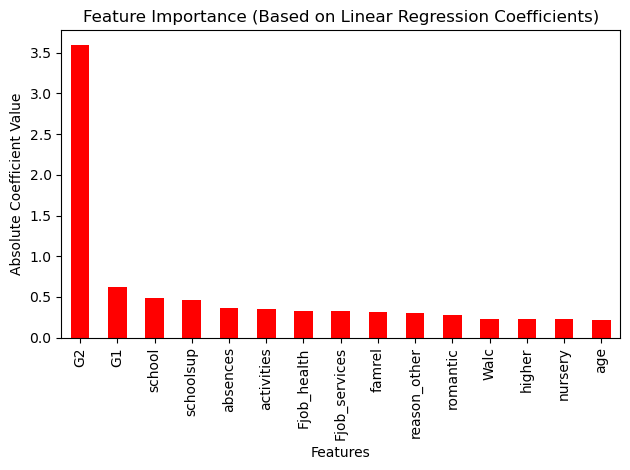

Model-Based Feature Importance saved to "feature_importances.png"!


In [86]:
#Model-Based Feature Importance
lr = LinearRegression()
lr.fit(X, y)
#We find the importance by taking the absolute value of the coefficients and sorting them in descending order.
featureImportances = pd.Series(np.abs(lr.coef_), index=X.columns).sort_values(ascending=False)
#Displays top 15 most impactful attributes
plt.figure()
featureImportances.head(15).plot(kind='bar', color='red')
plt.title('Feature Importance (Based on Linear Regression Coefficients)')
plt.ylabel('Absolute Coefficient Value')
plt.xlabel('Features')
plt.tight_layout()
plt.savefig('feature_importances.png')
plt.show()
print("Model-Based Feature Importance saved to \"feature_importances.png\"!")

In [87]:
#Save preprocessed file
try:
    preProcessedDataFile.to_csv('preprocessed_data.csv', index=False)
    print(f"Saved preprocessed_data.csv to this directory!")
except:
    print(f"Unable to save new preprocessed file. Did you make sure to close it before running this program?")

Saved preprocessed_data.csv to this directory!


# Model Training and Performance Evaluation

The following code block demonstrates our dataset being taken into a linear regression model, trained on an 80/20 split, and calculates the Mean Squared Error (MSE) and R^2 score. Though exact MSE and R^2 scores vary per run, on average MSE would be around 4-5 and R^2 would be around 0.75-0.8. Since the Mean Squared Error score is around 4-5, that means the student's grade point may have a prediction error of around 2-2.25 and since R^2 is around 0.75-0.8, this means the model has accounted for about 75-80% of variance in G3, the student's final grade. This implementation proves that even though we are taking tons of factors into consideration for our model, there are an infinite amount of untrackable variables that affect the student's grades, such as motivation or emotional struggles. This untrackable data results in our model not being anywhere near 100% accurate. But at the same time, if we had a higher R^2 score right now, it would be a sign that our data is overfitting.

In [ ]:
#80% of the model will be for train, 20% will be for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,test_size=0.2)
#Model is trained on Linear Regression
predictive_model = LinearRegression()
predictive_model.fit(X_train, y_train)
print(f"Linear Regression Model Results:")
#Calculate our predictions that'll be used for MSE and R^2
y_pred = predictive_model.predict(X_test)
#Mean Squared Error formula = ((sum of yi -yihat)^2)/n
#MSE can range from 1.7-9, but mostly likely around 4-5 (RMSE 2-2.25)
MSE = np.sum((y_test - y_pred) ** 2)/len(y_test)
#R^2 score formula = 1 - (SSRes/SSTotal)
#Where SSRes is the sum of squared residuals and SSTotal is the total sum of the squares
#Score is ~0.62-0.90
SSRes = np.sum((y_test - y_pred) ** 2)
SSTotal = np.sum((y_test - np.mean(y_test)) ** 2)
R2 = 1 - (SSRes / SSTotal)
print(f"Mean Squared Error: {MSE:.2f}")
print(f"R^2 Score: {R2:.2f}")

Model Used: Linear Regression
Mean Squared Error: 3.20
R^2 Score: 0.82
